<a href="https://colab.research.google.com/github/tmandiveyi/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Tapiwanashe Mandiveyi**

**ID: 58252028**

**Lab 2: Supervised and Unsupervised Learning**

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# Dataset URLs
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


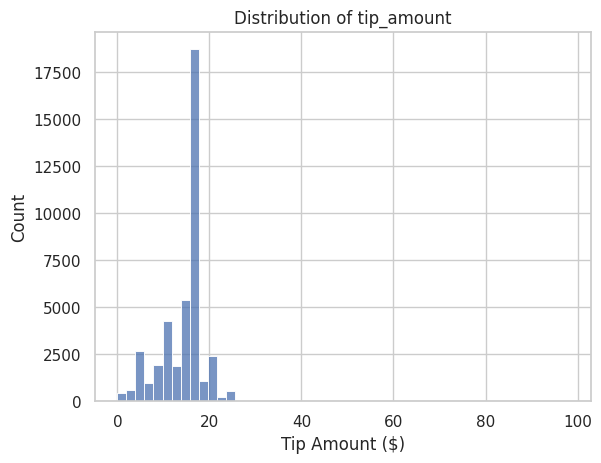

In [ ]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

taxi = pd.read_csv(TAXI_URL)

print(taxi.shape)
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()

sns.histplot(taxi['tip_amount'], bins=50)
plt.title('Distribution of tip_amount')
plt.xlabel('Tip Amount ($)')
plt.show()

My taxi dataset has 41,202 rows and 13 columns, with no missing values in any column. However, the tip_amount distribution is not zero-inflated as I expected — it's heavily concentrated between 10 and 20 with a sharp peak around 16–17, and tapers off quickly after 25. This unusual spike suggests many trips may be similarly priced (e.g. fixed-rate trips like airport rides), so I'll need to check for outliers beyond $25 and still validate other columns like trip_distance and fare_amount for zero or negative values even though nothing is missing.

In [ ]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

taxi_clean = taxi.dropna().copy()
taxi_clean = taxi_clean[(taxi_clean['trip_distance'] > 0) & (taxi_clean['fare_amount'] > 0)]
taxi_clean = taxi_clean[taxi_clean['tip_amount'] >= 0]

taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']
taxi_clean['total_surcharges'] = (taxi_clean['mta_tax'] + taxi_clean['tolls_amount']
                                   + taxi_clean['improvement_surcharge'])

cat_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
taxi_clean = pd.get_dummies(taxi_clean, columns=cat_cols, drop_first=True)

Rows having NaN values, zero or negative fares/distance, and negative tips are removed from the dataset as data entry errors instead of being imputed due to their low percentage in the data and that imputation would introduce a biased dataset. fare_per_mile denotes the pricing pressure for each ride and surcharges denotes other small charges for each ride and hence doesn’t include tip_amount so there is no leakage. Categorical variables are dummy coded using (drop_first=True to avoid dummy trap).

In [ ]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = taxi_clean.drop(columns=['tip_amount'])
y = taxi_clean['tip_amount']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

A 60/20/20 split reserves a validation set for model comparison while keeping the test set untouched until final evaluation, giving an unbiased  and correct performance estimate. The scaler is fit only on train because fitting on val/test would leak their distributional information into training, producing an overly optimistic evaluation.

LinearRegression Train: RMSE=4.804, R2=0.051
LinearRegression Val: RMSE=5.037, R2=0.049
LinearRegression Test: RMSE=5.013, R2=0.051
RandomForest Train: RMSE=4.604, R2=0.129
RandomForest Val: RMSE=5.066, R2=0.038
RandomForest Test: RMSE=5.035, R2=0.043


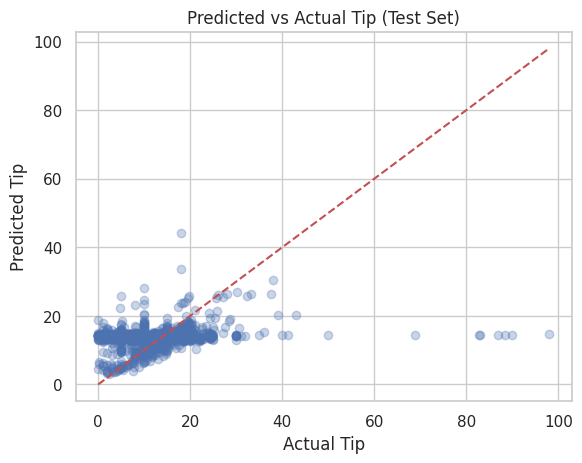

In [ ]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, name):
    for split_name, Xs, ys in [('Train', X_train_scaled, y_train),
                                ('Val', X_val_scaled, y_val),
                                ('Test', X_test_scaled, y_test)]:
        preds = model.predict(Xs)
        rmse = mean_squared_error(ys, preds) ** 0.5
        r2 = r2_score(ys, preds)
        print(f"{name} {split_name}: RMSE={rmse:.3f}, R2={r2:.3f}")

lr = LinearRegression().fit(X_train_scaled, y_train)
evaluate(lr, "LinearRegression")

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
evaluate(rf, "RandomForest")

best_model = rf
test_preds = best_model.predict(X_test_scaled)

plt.scatter(y_test, test_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Predicted vs Actual Tip (Test Set)')
plt.show()

Looking at the predicted-vs-actual plot, most predictions cluster tightly in the 10–20 range regardless of the actual tip value — for actual tips above 30–40, the model still predicts around 15, showing it's not capturing large tips at all. This flat horizontal band far from the red y=x line suggests underfitting rather than overfitting: the model has essentially learned to predict "the average tip" instead of responding to trip-specific features. To improve this, I'd try a more flexible model (deeper trees, more estimators) or add features that better explain large tips, such as trip duration or time-of-day, since fare-based features alone may not be capturing what drives high-tip trips.

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

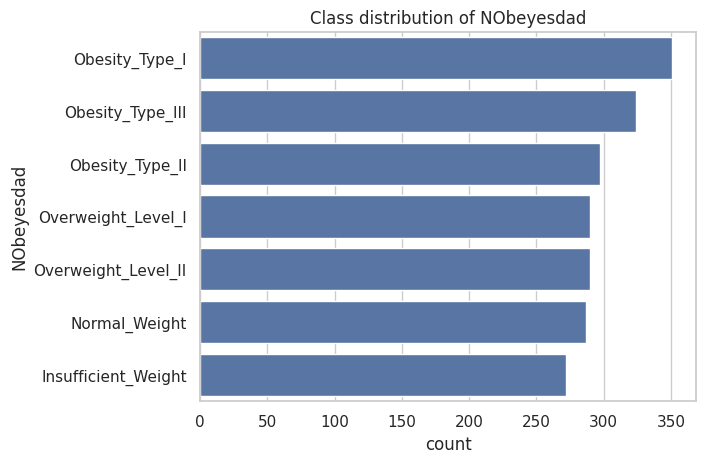

In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

# TODO: Inspect shape, head, info, describe, and missing values.

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?

obesity = pd.read_csv(OBESITY_URL)

print(obesity.shape)
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()

print(obesity['NObeyesdad'].value_counts())
sns.countplot(data=obesity, y='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('Class distribution of NObeyesdad')
plt.show()

The obesity dataset has 2,111 rows and 17 columns, with no missing values anywhere. Eight columns are numeric (Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE) and eight are categorical/object type (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS). The target is fairly well balanced across the 7 classes, ranging from 272 (Insufficient_Weight) to 351 (Obesity_Type_I) - no class dominates or is severely underrepresented. This balance matters because with imbalanced classes a model could achieve high accuracy just by favoring majority classes while ignoring minority ones, but since the counts here are all reasonably close, accuracy should be a fairly reliable metric alongside macro-F1.

In [ ]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

obesity_enc = obesity.copy()

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity_enc[col] = (obesity_enc[col] == 'yes').astype(int)

ordinal_cols = ['CAEC', 'CALC']
ordinal_order = [['no', 'Sometimes', 'Frequently', 'Always']] * len(ordinal_cols)
obesity_enc[ordinal_cols] = OrdinalEncoder(categories=ordinal_order).fit_transform(obesity_enc[ordinal_cols])

obesity_enc = pd.get_dummies(obesity_enc, columns=['Gender', 'MTRANS'], drop_first=True)

obesity_enc['BMI'] = obesity_enc['Weight'] / (obesity_enc['Height'] ** 2)

target_encoder = LabelEncoder()
obesity_enc['NObeyesdad_encoded'] = target_encoder.fit_transform(obesity_enc['NObeyesdad'])

I encoded the binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) directly as 0/1 since they only have two values with no ordering. For CAEC and CALC I used an ordinal encoding (no < Sometimes < Frequently < Always) since eating/drinking frequency naturally increases in that order, while Gender and MTRANS were one-hot encoded since they're just categories with no inherent rank. I also engineered BMI (Weight / Height²) since it's a well-known clinical predictor of obesity, but I'd argue it borders on unfair to include - the NObeyesdad categories in this dataset were likely defined using BMI thresholds in the first place, so adding it risks the model just learning the threshold rule rather than genuinely learning from lifestyle and physical features. I used StandardScaler for the numeric columns since features like Age and Weight have different scales and aren't strictly bounded, so standardizing puts them on comparable footing for distance-based and regularized models.

In [ ]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

# TODO: Fit the scaler on the training set only, then transform train / val / test.

X_ob = obesity_enc.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'])
y_ob = obesity_enc['NObeyesdad_encoded']

X_ob_temp, X_ob_test, y_ob_temp, y_ob_test = train_test_split(
    X_ob, y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob
)
X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_temp, y_ob_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ob_temp
)

ob_scaler = StandardScaler()
X_ob_train_scaled = ob_scaler.fit_transform(X_ob_train)
X_ob_val_scaled = ob_scaler.transform(X_ob_val)
X_ob_test_scaled = ob_scaler.transform(X_ob_test)

I used the same 60/20/20 train/validation/test split as before, but with stratify=y on both split calls so each set keeps the same proportion of all 7 obesity classes as the full dataset. This matters because the classes, while fairly balanced, are not perfectly equal in count (272–351 per class), so a random split without stratification could still shift those proportions around by chance, leaving one split with noticeably fewer examples of a class like Insufficient_Weight. If that happened, the model might underlearn that class during training, or the validation/test metrics could look misleadingly good or bad simply due to an unlucky split rather than genuine model performance.

LogisticRegression Train: Accuracy=0.924, Macro-F1=0.922
LogisticRegression Val: Accuracy=0.879, Macro-F1=0.873
LogisticRegression Test: Accuracy=0.894, Macro-F1=0.890
RandomForest Train: Accuracy=1.000, Macro-F1=1.000
RandomForest Val: Accuracy=0.993, Macro-F1=0.993
RandomForest Test: Accuracy=0.993, Macro-F1=0.993
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.98      0.98      0.98        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



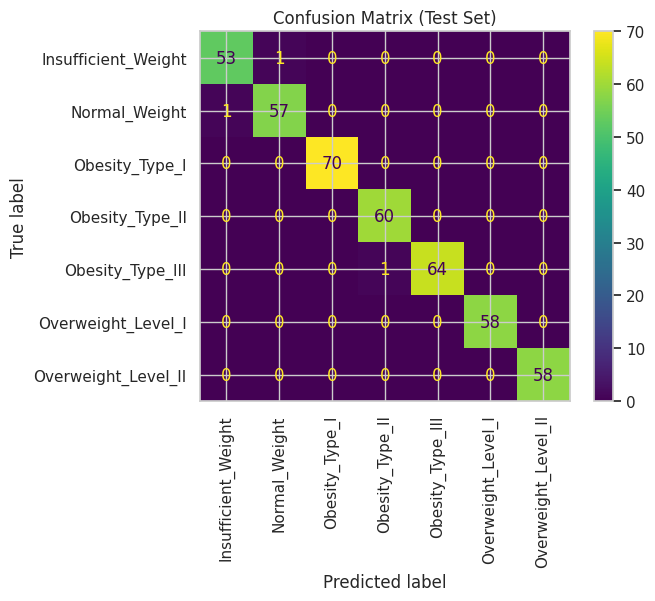

In [ ]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

def evaluate_clf(model, name):
    for split_name, Xs, ys in [('Train', X_ob_train_scaled, y_ob_train),
                                ('Val', X_ob_val_scaled, y_ob_val),
                                ('Test', X_ob_test_scaled, y_ob_test)]:
        preds = model.predict(Xs)
        acc = accuracy_score(ys, preds)
        f1 = f1_score(ys, preds, average='macro')
        print(f"{name} {split_name}: Accuracy={acc:.3f}, Macro-F1={f1:.3f}")

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_ob_train_scaled, y_ob_train)
evaluate_clf(log_reg, "LogisticRegression")

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE)
rf_clf.fit(X_ob_train_scaled, y_ob_train)
evaluate_clf(rf_clf, "RandomForest")

best_clf = rf_clf  # update based on actual val performance
test_preds = best_clf.predict(X_ob_test_scaled)

print(classification_report(y_ob_test, test_preds, target_names=target_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(
    y_ob_test, test_preds, display_labels=target_encoder.classes_, xticks_rotation=90
)
plt.title('Confusion Matrix (Test Set)')
plt.show()

RandomForest clearly outperformed LogisticRegression, hitting 99.3% accuracy and 0.993 macro-F1 on both validation and test, compared to LogisticRegression's 88-89%. Comparing RandomForest's train (100% accuracy) to its validation and test scores (99.3% both), the gap is tiny - only a few points off perfect - so this looks well-fitted rather than overfitting, especially since validation and test track each other almost exactly. The confusion matrix confirms this: nearly every class is classified perfectly, with only 2–3 misclassifications total, mostly between adjacent classes like Insufficient_Weight/Normal_Weight and Obesity_Type_III/Overweight_Level_I - these are the hardest to separate because their physical measurements sit right at the boundary thresholds between categories.

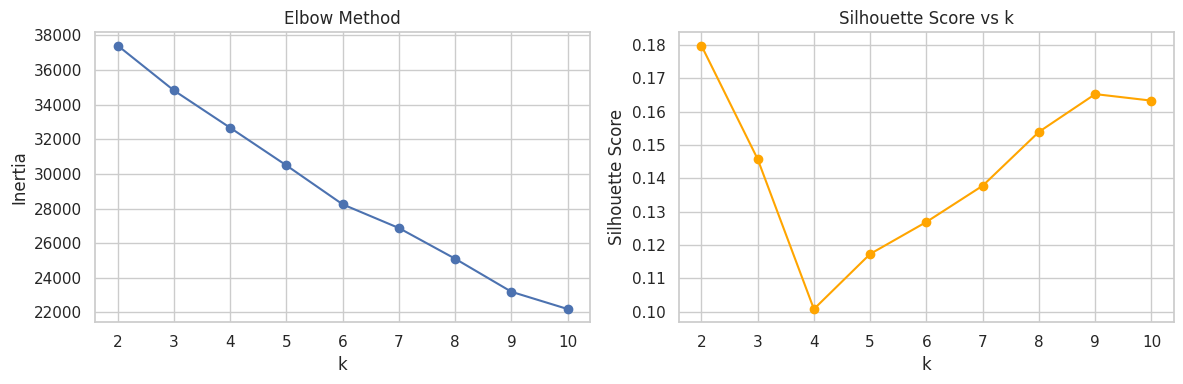

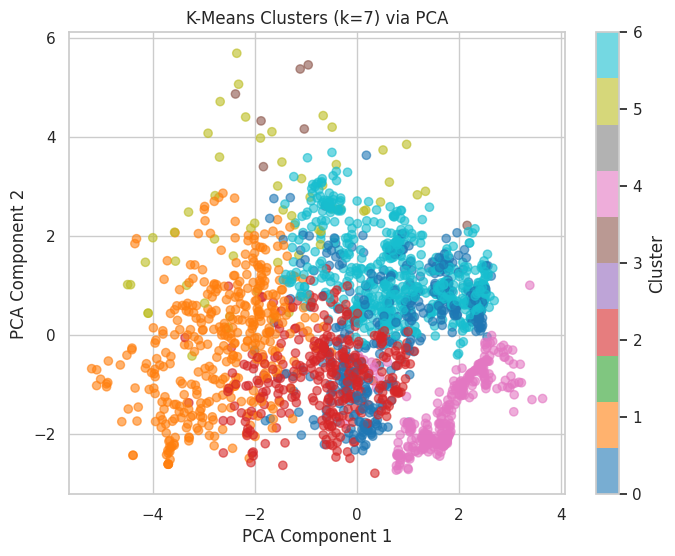

In [ ]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use the full scaled obesity feature matrix (train+val+test combined, since this is unsupervised)
X_ob_all_scaled = ob_scaler.transform(X_ob)

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_ob_all_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_ob_all_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
plt.tight_layout()
plt.show()

CHOSEN_K = 7

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_ob_all_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_ob_all_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means Clusters (k={CHOSEN_K}) via PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

crosstab = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
print(crosstab)

NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             0             22             109   
1                           188            149               2   
2                             3             38             109   
3                             0              4               0   
4                             0              0               4   
5                             6             32               2   
6                            75             42             125   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                       100                 0                  57   
1                         1                 0                  40   
2                        48                 0                  88   
3                         1                 0               

The elbow plot doesn't show a sharp bend - inertia decreases fairly steadily from k=2 to k=10 without an obvious "elbow" - while the silhouette score actually peaks at k=2 (0.18) and dips lowest at k=4, then climbs back up toward k=9–10. Despite the silhouette technically favoring k=2, I chose k=7 to match the number of known obesity categories and make the clusters interpretable against the true labels, even though the metrics suggest the data doesn't naturally separate into 7 tight, well-defined groups.

Looking at the crosstab, some clusters align very cleanly with true classes - cluster 4 is almost entirely Obesity_Type_III (324 of 330 members), and cluster 0 leans heavily toward Overweight_Level_II. But other clusters are much messier: cluster 1 mixes Insufficient_Weight (188) and Normal_Weight (149) together, and cluster 6 spreads across Normal_Weight, Overweight_Level_I, Obesity_Type_II, and Overweight_Level_II fairly evenly. This confirms what I would expect - K-Means separates the most physically extreme class (severe obesity) well, since those points are genuinely far away in feature space, but it can't cleanly resolve the middle categories, which blend into each other along a continuous spectrum rather than forming distinct clusters.

In a real public-health setting, these clusters would still be useful for triage even without perfect label agreement - I could flag the clean, extreme cluster (like cluster 4) for immediate outreach, while treating the blended middle clusters as a broader "at-risk" group needing further individual assessment rather than precise categorization.

# Reflection



1. Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?

The classifier had an advantage - it got to see the real obesity labels, so it learned the exact patterns that separate each category and reached 99% accuracy. K-Means never saw those labels, so it could only group people based on how similar their features looked, which is why it correctly identified the most extreme group (Obesity_Type_III) but mixed up the middle categories that overlap more. What K-Means showed me that the classifier couldn't is that the data doesn't naturally split into 7 distinct groups - it's more of a continuous scale with a couple of clear extremes and a lot of blending in between.

2. Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

Evaluating the tip prediction was harder to judge than the obesity classifier. For tips, I had to look at RMSE, R², and a scatter plot to figure out how far off the predictions were, and it took some digging to notice the model was just predicting around $15 for almost everything. For the obesity classifier, it was much easier to tell how well it worked - accuracy and macro-F1 gave clear percentages, and the confusion matrix showed exactly which classes were being confused, so there was much less guesswork involved.

3. Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

The regression model had the biggest problem, but it was actually underfitting rather than overfitting - predictions stayed flat around 15 even when actual tips went up to 100, meaning the model wasn't using the features well enough to predict larger tips. The obesity classifier, on the other hand, barely had a gap at all - it went from 100% accuracy on training to 99.3% on test, which is about as close as it gets. If I had to fix one model, it would be the tip regressor, and the most effective change would be adding better features like trip duration or time of day, since the current fare-based features clearly weren't giving the model enough information to predict tips accurately.